# Tutorial 04 — AI for Vision with PyTorch

**Topics:** batch normalization, dropout, CNNs, CIFAR-10, Vision Transformers, and transfer learning  

This tutorial follows Lecture 4's path from image tensors to modern visual encoders. 

Complete every `TODO`, run all cells in order, and retain the outputs. Use the solution notebook only after attempting each task.


## Submission

Please submit:

- Your completed `Tutorial04_AI_for_Vision_Student.ipynb` (student) / this file is the instructor key
- `your_model_weights.pth` 
- Optional: `submission_YourName.xlsx` 

**Checklist**

* All `###YOUR CODE HERE###` sections in Q1–Q6 code sections are filled
* Short written answers in **Q1–Q4** are completed

> Keep the section structure so grading scripts (if any) can find your answers.

## 0. Setup

The notebook runs on CPU, Apple Silicon (`mps`), or CUDA. By default it uses `torchvision.datasets.FakeData`, so every cell works offline. Set `USE_CIFAR10 = True` in Task 4 to download and train on CIFAR-10.


In [1]:
from pathlib import Path
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

try:
    from torchvision import datasets, transforms
except Exception as exc:
    raise RuntimeError("Install matching torch and torchvision packages before continuing.") from exc

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


PyTorch: 2.6.0
Device: mps


In [2]:
# --- Run configuration -------------------------------------------------------
# Small amount of shared bookkeeping used by every task below: where outputs go,
# the CIFAR-10 class names, a re-seeding helper so each training run starts from
# the same state, and a results table that Task 7 turns into the submission
# spreadsheet.
import math

import pandas as pd

STUDENT_NAME = "Nhat Quang Nguyen"
OUTPUT_DIR = Path(".")
CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

RESULTS = []          # one row per trained model
ARTIFACTS = {}        # confusion matrices / predictions kept for the report


def set_seed(seed: int = SEED) -> None:
    """Re-seed every RNG so runs are reproducible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def count_parameters(module: nn.Module, trainable_only: bool = False) -> int:
    params = module.parameters()
    if trainable_only:
        params = (p for p in module.parameters() if p.requires_grad)
    return sum(p.numel() for p in params)


def record_result(name, description, test_accuracy, params, epochs, seconds, checkpoint=""):
    RESULTS.append({
        "model": name,
        "description": description,
        "test_accuracy": round(float(test_accuracy), 4),
        "test_error": round(1.0 - float(test_accuracy), 4),
        "parameters": int(params),
        "epochs": int(epochs),
        "train_seconds": round(float(seconds), 1),
        "checkpoint": str(checkpoint),
    })
    print(f"recorded: {name} -> test accuracy {test_accuracy:.4f}")


print("student:", STUDENT_NAME)
print("outputs will be written to:", OUTPUT_DIR.resolve())

student: Nhat Quang Nguyen
outputs will be written to: /Users/quangnguyen/Downloads


## 1. Batch Normalization

For a mini-batch channel with mean $\mu_B$ and variance $\sigma_B^2$,

$$\hat{x}=\frac{x-\mu_B}{\sqrt{\sigma_B^2+\epsilon}},\qquad y=\gamma\hat{x}+\beta.$$

Batch normalization learns $\gamma$ and $\beta$. During training it also updates running statistics; during evaluation it uses those running statistics.

**TODO 1.1:** implement the training-mode normalization below.  
**TODO 1.2:** explain why `train()` and `eval()` can produce different results for the same input.


In [3]:
def batch_norm_2d_train(x, gamma, beta, eps=1e-5):
    # Normalize NCHW input independently for every channel.
    # TODO 1.1: compute mean/variance over N, H, W and return y.
    #
    # A "channel" is one feature map, so its statistics are pooled over the batch
    # axis N and both spatial axes H, W -- but never over C. keepdim=True leaves the
    # statistics with shape (1, C, 1, 1) so they broadcast back against x.
    mean = x.mean(dim=(0, 2, 3), keepdim=True)
    # Biased variance (divide by m, not m-1). This is what nn.BatchNorm2d uses to
    # normalize; the unbiased estimate is only used for the running variance.
    var = x.var(dim=(0, 2, 3), keepdim=True, unbiased=False)
    # eps inside the square root keeps the division safe for a near-constant channel.
    x_hat = (x - mean) / torch.sqrt(var + eps)
    # The learnable affine gives the layer back the ability to represent any
    # mean/scale, so normalization does not cost the network expressiveness.
    y = gamma * x_hat + beta
    return y, mean, var

x = torch.randn(8, 3, 16, 16)
gamma = torch.ones(1, 3, 1, 1)
beta = torch.zeros(1, 3, 1, 1)
y, mean, var = batch_norm_2d_train(x, gamma, beta)

assert y is not None, "Complete TODO 1.1"
print("output channel means:", y.mean(dim=(0, 2, 3)))
print("output channel variances:", y.var(dim=(0, 2, 3), unbiased=False))

# Statistics are per channel, so mean/var carry one number per channel.
print("mean shape:", tuple(mean.shape), "var shape:", tuple(var.shape))

# Cross-check against PyTorch's own implementation (affine off, so gamma=1, beta=0).
reference = nn.BatchNorm2d(3, eps=1e-5, affine=False, track_running_stats=False).train()
print("max |ours - nn.BatchNorm2d|:", (y - reference(x)).abs().max().item())

# The affine part really is applied: scale channel 0 by 2 and shift it by 5.
gamma2 = torch.tensor([2.0, 1.0, 1.0]).view(1, 3, 1, 1)
beta2 = torch.tensor([5.0, 0.0, 0.0]).view(1, 3, 1, 1)
y2, _, _ = batch_norm_2d_train(x, gamma2, beta2)
print("channel means after affine:", y2.mean(dim=(0, 2, 3)))
print("channel stds  after affine:", y2.std(dim=(0, 2, 3), unbiased=False))

output channel means: tensor([9.3132e-09, 4.6566e-09, 9.3132e-09])
output channel variances: tensor([1.0000, 1.0000, 1.0000])
mean shape: (1, 3, 1, 1) var shape: (1, 3, 1, 1)
max |ours - nn.BatchNorm2d|: 2.384185791015625e-07
channel means after affine: tensor([5.0000e+00, 4.6566e-09, 9.3132e-09])
channel stds  after affine: tensor([2.0000, 1.0000, 1.0000])


### TODO Answer 1.2

Write 2–3 sentences here. Mention mini-batch statistics and running statistics.

**Answer.** In `train()` mode the layer normalizes each channel with the mean and
variance **of the current mini-batch**, so one image's output depends on the other
images it happens to be batched with — change the batch, its size, or even the
shuffle order and the same input produces different activations (this batch noise
is part of why BatchNorm regularizes). In `eval()` mode the layer instead uses the
**running statistics**, an exponential moving average of the training batch
means/variances stored in `running_mean` / `running_var`, which are frozen
constants; the layer collapses to a deterministic per-channel affine map, so an
image is scored identically no matter what it is batched with (and batch size 1
works). The two modes therefore disagree whenever the batch statistics differ from
the running ones — most visibly early in training, with very small or non-i.i.d.
batches, or under distribution shift — which is exactly why forgetting
`model.eval()` at test time is such a common source of "my accuracy dropped"
bugs. (The same switch also turns dropout off, see Task 2.)

## 2. Dropout

Dropout independently masks activations with probability $p$ during training. PyTorch uses *inverted dropout*: surviving activations are divided by $1-p$, preserving their expected value. In evaluation mode dropout is the identity function.

**TODO 2.1:** implement inverted dropout.  


In [4]:
def inverted_dropout(x, p=0.5, training=True):
    if not training or p == 0:
        return x
    if not 0 <= p < 1:
        raise ValueError("p must satisfy 0 <= p < 1")
    # TODO 2.1: sample a Bernoulli mask and apply inverted-dropout scaling.
    #
    # Every activation is kept independently with probability keep_prob = 1 - p.
    # torch.rand_like draws U(0, 1) with the same shape/dtype/device as x, so the
    # comparison is an elementwise Bernoulli(keep_prob) sample.
    keep_prob = 1.0 - p
    mask = (torch.rand_like(x) < keep_prob).to(x.dtype)
    # Dividing by keep_prob at TRAIN time restores the expectation:
    #   E[mask * x / keep_prob] = keep_prob * x / keep_prob = x.
    # That is what makes eval() a plain identity -- no rescaling at inference.
    return x * mask / keep_prob

signal = torch.ones(20_000)
dropped = inverted_dropout(signal, p=0.4, training=True)
assert dropped is not None, "Complete TODO 2.1"
print("fraction zero:", (dropped == 0).float().mean().item())
print("mean after inverted dropout:", dropped.mean().item())

# Expected value is preserved (should be ~1.0) and evaluation is the identity.
print("|mean - 1.0|:", abs(dropped.mean().item() - 1.0))
print("surviving value:", dropped[dropped != 0][0].item(), "= 1 / (1 - p) =", 1 / 0.6)
print("eval mode is the identity?",
      torch.equal(inverted_dropout(signal, p=0.4, training=False), signal))

layer = nn.Dropout(p=0.4)
layer.train()
train_equal = torch.equal(layer(signal[:20]), layer(signal[:20]))
layer.eval()
eval_equal = torch.equal(layer(signal[:20]), layer(signal[:20]))
print("two training outputs equal?", train_equal)
print("two evaluation outputs equal?", eval_equal)

# Same statistics as nn.Dropout: a fresh mask every call in train(), identity in eval().
layer.train()
torch_dropped = layer(signal)
print("nn.Dropout fraction zero:", (torch_dropped == 0).float().mean().item(),
      "| mean:", torch_dropped.mean().item())

fraction zero: 0.40244999527931213
mean after inverted dropout: 0.9959167242050171
|mean - 1.0|: 0.00408327579498291
surviving value: 1.6666666269302368 = 1 / (1 - p) = 1.6666666666666667
eval mode is the identity? True
two training outputs equal? False
two evaluation outputs equal? True
nn.Dropout fraction zero: 0.39454999566078186 | mean: 1.0090833902359009


## 3. Build a Convolutional Neural Network

Lecture 4 emphasizes repeated blocks of convolution, non-linearity, and downsampling, followed by a classifier. For a 2D convolution,

$$H_{out}=\left\lfloor\frac{H+2P-D(K-1)-1}{S}+1\right\rfloor.$$

**TODO 3.1:** complete `VisionCNN` with three convolutional blocks. Each block must contain `Conv2d → BatchNorm2d → ReLU`; the first two blocks also use max pooling. Add dropout before the final linear classifier.  
**TODO 3.2:** calculate the feature-map shapes for a batch of $32\times32$ RGB images.


In [5]:
class VisionCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.35):
        super().__init__()
        # TODO 3.1: build 3 -> 32 -> 64 -> 128 convolutional blocks.
        # Use kernel_size=3, padding=1, and 2x2 pooling after blocks 1 and 2.
        #
        # kernel_size=3 with padding=1 and stride=1 is "same" padding:
        #   H_out = floor((H + 2*1 - 1*(3-1) - 1) / 1 + 1) = H,
        # so only the MaxPool2d layers change the resolution. Conv2d(bias=False)
        # because the BatchNorm that follows subtracts the mean anyway -- its beta
        # already plays the role of the bias.
        self.features = nn.Sequential(
            # Block 1: 3 -> 32 channels, 32x32 -> 16x16
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 2: 32 -> 64 channels, 16x16 -> 8x8
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Block 3: 64 -> 128 channels, resolution unchanged (8x8)
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # Global average pooling -> 128 x 1 x 1 for any input resolution.
            nn.AdaptiveAvgPool2d(output_size=1),
        )
        # Dropout sits directly before the only linear layer, where the parameter
        # count (and therefore the overfitting risk) is concentrated.
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout_p),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

model = VisionCNN().to(DEVICE)
dummy = torch.randn(4, 3, 32, 32, device=DEVICE)
assert model.features is not None and model.classifier is not None, "Complete TODO 3.1"
logits = model(dummy)
print(model)
print("input:", tuple(dummy.shape), "logits:", tuple(logits.shape))
assert logits.shape == (4, 10)

# Shape trace for TODO 3.2 (batch dimension omitted in the printout).
print("\nshape trace, C x H x W")
print(f"{'input':<22} -> {tuple(dummy.shape[1:])}")
with torch.no_grad():
    h = dummy
    for layer in model.features:
        h = layer(h)
        print(f"{layer.__class__.__name__:<22} -> {tuple(h.shape[1:])}")
print(f"{'flatten + classifier':<22} -> {tuple(model(dummy).shape[1:])}")
print("\ntrainable parameters:", sum(p.numel() for p in model.parameters()))

# Adaptive pooling makes the network resolution-agnostic: a 64x64 input still
# produces 10 logits, with no change to the classifier.
print("64x64 input ->", tuple(model(torch.randn(2, 3, 64, 64, device=DEVICE)).shape))

VisionCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.35, inplace=False)
    (1): Linear(in_features=128, out_features=10, bias=True)
  )
)

### TODO Answer 3.2

Complete the shape trace (omit the batch dimension):

| Stage | Shape $C\times H\times W$ |
|---|---|
| Input | $3\times32\times32$ |
| Block 1 + pool | $32\times16\times16$ |
| Block 2 + pool | $64\times8\times8$ |
| Block 3 | $128\times8\times8$ |
| Adaptive average pool | $128\times1\times1$ |

Every convolution uses $K=3$, $P=1$, $S=1$, $D=1$, so

$$H_{out}=\left\lfloor\frac{H+2\cdot1-1\cdot(3-1)-1}{1}+1\right\rfloor=H,$$

i.e. the convolutions preserve resolution and only the two $2\times2$ max-pools
halve it ($32\to16\to8$). Block 3 has no pooling, so it only changes the channel
count ($64\to128$). The flattened classifier input is therefore $128\cdot1\cdot1=128$
features.

**Why is adaptive average pooling convenient when the input resolution changes?**
`nn.AdaptiveAvgPool2d(1)` is told the *output* size rather than the kernel size, so
it chooses its own pooling window and always emits $C\times1\times1$ — one number
per channel — whatever $H\times W$ it receives. The classifier's input dimension is
then fixed at $C$ and depends only on the channel count, so the same weights accept
$32\times32$, $64\times64$ or $224\times224$ images without a shape error and
without retraining the head (verified in the cell above). A flatten of the raw
$128\times8\times8$ map would instead hard-code $8192$ inputs, breaking on any other
resolution, and would carry $8192\times10$ weights instead of $128\times10$ — global
average pooling is both resolution-independent and a strong structural regularizer,
since it forces each channel to behave as a class-evidence detector averaged over
all spatial positions (which also makes it translation-invariant).

## 4. PyTorch on CIFAR-10 — 35 minutes

CIFAR-10 contains 60,000 colour images in 10 classes: 50,000 training images and 10,000 test images. The cell below defaults to a small synthetic dataset for fast, offline checking. Set `USE_CIFAR10 = True` for the real exercise.

**TODO 4.1:** define training augmentation and evaluation preprocessing.  
**TODO 4.2:** complete one epoch of supervised training.  
**TODO 4.3:** report test accuracy and a $10\times10$ confusion matrix.


In [6]:
USE_CIFAR10 = True
BATCH_SIZE = 128

# TODO 4.1: add random crop with padding=4 and random horizontal flip for training.
# Both transforms must finish with ToTensor and CIFAR-10 normalization.
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2470, 0.2435, 0.2616)

# Training pipeline: the two augmentations are the standard CIFAR-10 pair.
#   RandomCrop(32, padding=4) pads to 40x40 and crops a random 32x32 window, i.e. a
#     random shift of up to +/-4 px -- it teaches translation robustness.
#   RandomHorizontalFlip() exploits the left/right symmetry of these object classes.
# Both act on the PIL image, BEFORE ToTensor(); geometry first, then tensor +
# normalization. Normalize maps each channel to roughly zero mean / unit variance,
# which keeps the first layer's activations well scaled.
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# Evaluation pipeline: deterministic. Never augment the test set -- the same image
# must always map to the same tensor, and the normalization must match training.
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

assert train_transform is not None and eval_transform is not None, "Complete TODO 4.1"
if USE_CIFAR10:
    train_set = datasets.CIFAR10("data", train=True, download=True, transform=train_transform)
    test_set = datasets.CIFAR10("data", train=False, download=True, transform=eval_transform)
else:
    train_set = datasets.FakeData(1024, image_size=(3, 32, 32), num_classes=10, transform=eval_transform)
    test_set = datasets.FakeData(256, image_size=(3, 32, 32), num_classes=10, transform=eval_transform)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(len(train_set), "training images;", len(test_set), "test images")

# Sanity check: one training batch, and the normalized statistics.
images, labels = next(iter(train_loader))
print("batch:", tuple(images.shape), "labels:", tuple(labels.shape), labels[:8].tolist())
print("per-channel mean after normalization:", images.mean(dim=(0, 2, 3)).tolist())
print("per-channel std  after normalization:", images.std(dim=(0, 2, 3)).tolist())
if USE_CIFAR10:
    print("classes:", train_set.classes)

50000 training images; 10000 test images
batch: (128, 3, 32, 32) labels: (128,) [5, 2, 4, 2, 6, 8, 0, 5]
per-channel mean after normalization: [-0.28888019919395447, -0.3129444420337677, -0.27404627203941345]
per-channel std  after normalization: [1.1231915950775146, 1.0976301431655884, 1.040963053703308]
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


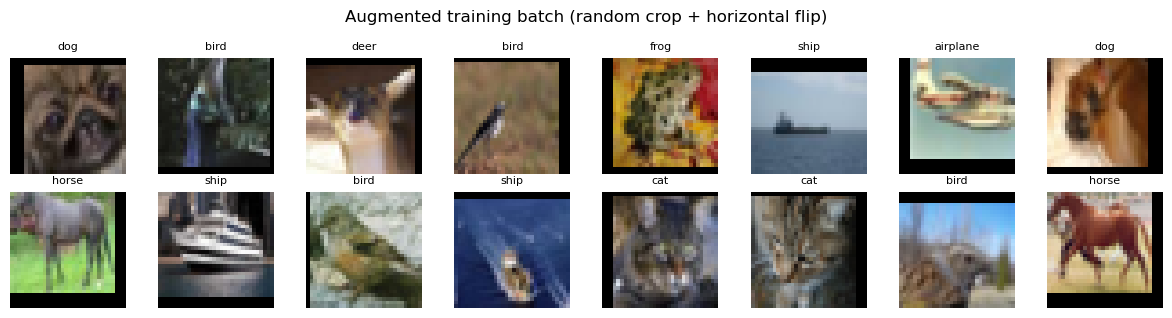

In [7]:
# A quick look at the augmented training batch (de-normalized for display).
mean_t = torch.tensor(CIFAR_MEAN).view(1, 3, 1, 1)
std_t = torch.tensor(CIFAR_STD).view(1, 3, 1, 1)
grid = (images[:16] * std_t + mean_t).clamp(0, 1).permute(0, 2, 3, 1).numpy()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, img, label in zip(axes.ravel(), grid, labels[:16].tolist()):
    ax.imshow(img)
    ax.set_title(CLASS_NAMES[label] if USE_CIFAR10 else str(label), fontsize=8)
    ax.axis("off")
fig.suptitle("Augmented training batch (random crop + horizontal flip)")
plt.tight_layout()
plt.show()

In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()   # BatchNorm uses batch statistics, Dropout is active
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # TODO 4.2: clear gradients, run forward pass, compute loss,
        # backpropagate, update parameters, and accumulate metrics.
        optimizer.zero_grad(set_to_none=True)   # gradients accumulate by default
        logits = model(images)                  # forward pass -> (B, num_classes)
        loss = criterion(logits, labels)        # mean cross-entropy over the batch
        loss.backward()                         # backprop: dL/dtheta for every parameter
        optimizer.step()                        # AdamW parameter update

        batch_size = labels.size(0)
        # criterion returns a batch MEAN, so re-weight by the batch size before
        # summing; the last batch may be smaller than BATCH_SIZE.
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += batch_size
    return total_loss / total_examples, total_correct / total_examples

set_seed()
model = VisionCNN(num_classes=10).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

EPOCHS = 1 if not USE_CIFAR10 else 10
baseline_start = time.time()
for epoch in range(EPOCHS):
    loss, accuracy = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    print(f"epoch {epoch + 1:02d}: loss={loss:.4f}, train_acc={accuracy:.3f}, "
          f"elapsed={time.time() - baseline_start:.0f}s")
baseline_seconds = time.time() - baseline_start
print(f"training finished in {baseline_seconds:.0f}s on {DEVICE}")

epoch 01: loss=1.5439, train_acc=0.431, elapsed=14s


epoch 02: loss=1.2865, train_acc=0.538, elapsed=26s


epoch 03: loss=1.1810, train_acc=0.576, elapsed=38s


epoch 04: loss=1.1216, train_acc=0.600, elapsed=50s


epoch 05: loss=1.0588, train_acc=0.624, elapsed=61s


epoch 06: loss=1.0208, train_acc=0.640, elapsed=73s


epoch 07: loss=0.9858, train_acc=0.653, elapsed=84s


epoch 08: loss=0.9534, train_acc=0.663, elapsed=96s


epoch 09: loss=0.9279, train_acc=0.674, elapsed=108s


epoch 10: loss=0.9035, train_acc=0.682, elapsed=121s
training finished in 121s on mps


test accuracy: 0.704
tensor([[730,  35,  62,   7,  16,   3,  10,  31,  75,  31],
        [ 26, 859,   6,   4,   5,   7,   6,  18,   9,  60],
        [ 75,   4, 540,  30, 129,  45,  83,  77,  11,   6],
        [ 33,   8,  94, 344,  92, 196, 103, 102,  15,  13],
        [ 20,   1,  35,  15, 700,  21,  69, 129,   9,   1],
        [ 15,   6,  38,  97,  78, 626,  23, 106,   8,   3],
        [ 11,   1,  61,  34,  72,  14, 784,  21,   1,   1],
        [ 15,   0,  30,  12,  64,  26,   3, 840,   0,  10],
        [ 68,  31,  16,   5,  15,   3,   6,  14, 815,  27],
        [ 25,  88,   5,  11,   8,   1,   5,  34,  21, 802]])
confusion matrix total: 10000 | trace: 7040


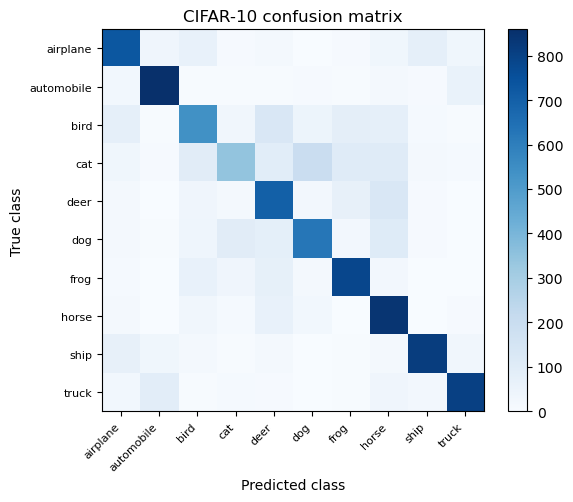

In [9]:
@torch.no_grad()
def evaluate(model, loader, num_classes, device):
    model.eval()   # BatchNorm switches to running statistics, Dropout becomes identity
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        # TODO 4.3: predict labels, accumulate accuracy and confusion[true, predicted].
        # argmax over the class axis: softmax is monotonic, so the largest logit is
        # already the most probable class -- no need to normalize.
        predictions = model(images).argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        # Flatten each (true, predicted) pair into a single index and count them in
        # one shot; row = true class, column = predicted class.
        pair = labels.cpu() * num_classes + predictions.cpu()
        confusion += torch.bincount(pair, minlength=num_classes ** 2).reshape(num_classes, num_classes)
    return correct / total, confusion

test_accuracy, confusion = evaluate(model, test_loader, 10, DEVICE)
print(f"test accuracy: {test_accuracy:.3f}")
print(confusion)
assert confusion.shape == (10, 10)

# Consistency checks: the matrix must account for every test image, and its trace
# must reproduce the accuracy that was counted independently.
assert confusion.sum().item() == len(test_set)
assert abs(confusion.diag().sum().item() / confusion.sum().item() - test_accuracy) < 1e-9
print("confusion matrix total:", confusion.sum().item(), "| trace:", confusion.diag().sum().item())

plt.figure(figsize=(6, 5))
plt.imshow(confusion.numpy(), cmap="Blues")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("CIFAR-10 confusion matrix" if USE_CIFAR10 else "Synthetic-data confusion matrix")
if USE_CIFAR10:
    plt.xticks(range(10), CLASS_NAMES, rotation=45, ha="right", fontsize=8)
    plt.yticks(range(10), CLASS_NAMES, fontsize=8)
plt.colorbar()
plt.tight_layout()
plt.show()

In [10]:
# --- Task 4 wrap-up: per-class accuracy and checkpoint ------------------------
support = confusion.sum(dim=1)                       # images per true class
per_class_correct = confusion.diag()
per_class_accuracy = per_class_correct.float() / support.clamp(min=1)

print(f"{'class':<12}{'accuracy':>10}{'correct':>10}{'support':>10}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<12}{per_class_accuracy[i].item():>10.3f}"
          f"{per_class_correct[i].item():>10d}{support[i].item():>10d}")
print(f"{'OVERALL':<12}{test_accuracy:>10.3f}"
      f"{per_class_correct.sum().item():>10d}{support.sum().item():>10d}")

# The largest off-diagonal entries are the pairs the network actually confuses.
off_diagonal = confusion.clone()
off_diagonal.fill_diagonal_(0)
values, flat_idx = off_diagonal.flatten().topk(5)
print("\ntop confusions (true -> predicted):")
for value, index in zip(values.tolist(), flat_idx.tolist()):
    print(f"  {CLASS_NAMES[index // 10]:>10} -> {CLASS_NAMES[index % 10]:<10} {value}")

baseline_cnn_checkpoint = OUTPUT_DIR / "vision_cnn_cifar10.pth"
torch.save(
    {
        "arch": "VisionCNN",
        "state_dict": model.state_dict(),
        "test_accuracy": test_accuracy,
        "num_classes": 10,
        "class_names": CLASS_NAMES,
        "normalization": {"mean": CIFAR_MEAN, "std": CIFAR_STD},
        "input_size": 32,
    },
    baseline_cnn_checkpoint,
)
print("\nsaved:", baseline_cnn_checkpoint)

ARTIFACTS["VisionCNN (baseline)"] = {"confusion": confusion.clone()}
record_result(
    name="VisionCNN (baseline)",
    description="Task 4: 3 conv blocks (BN+ReLU), GAP head, AdamW 2e-3, crop+flip",
    test_accuracy=test_accuracy,
    params=count_parameters(model),
    epochs=EPOCHS,
    seconds=baseline_seconds,
    checkpoint=baseline_cnn_checkpoint.name,
)

class         accuracy   correct   support
airplane         0.730       730      1000
automobile       0.859       859      1000
bird             0.540       540      1000
cat              0.344       344      1000
deer             0.700       700      1000
dog              0.626       626      1000
frog             0.784       784      1000
horse            0.840       840      1000
ship             0.815       815      1000
truck            0.802       802      1000
OVERALL          0.704      7040     10000

top confusions (true -> predicted):
         cat -> dog        196
        bird -> deer       129
        deer -> horse      129
         dog -> horse      106
         cat -> frog       103

saved: vision_cnn_cifar10.pth
recorded: VisionCNN (baseline) -> test accuracy 0.7040


## 5. Vision Transformer from Scratch

A ViT divides an image into non-overlapping patches, projects every patch to a token, prepends a learnable `[CLS]` token, adds positional embeddings, and processes the sequence using transformer encoder blocks.

For a $32\times32$ image and patch size 4, there are $(32/4)^2=64$ patch tokens and one class token. This task follows the from-scratch ViT requirement in the IOAI2026 notebook: use only `torch` and `torch.nn`, not a ready-made ViT.

**TODO 5.1:** convert convolutional patch features from `(B,D,H',W')` to `(B,N,D)`.  
**TODO 5.2:** concatenate the class token, add positional embeddings, apply transformer blocks, and classify the normalized class token.  
**TODO 5.3:** compare the inductive biases of the CNN and ViT.

**TODO 5.4:** Further improve the performance of the classification task, like deeper network, data augmentation, pre-trained model.

In [11]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        if image_size % patch_size:
            raise ValueError("image_size must be divisible by patch_size")
        self.num_patches = (image_size // patch_size) ** 2
        # A Conv2d with kernel_size == stride == patch_size IS the patch projection:
        # each output position sees exactly one non-overlapping patch and applies the
        # same linear map (patch_size^2 * in_channels -> embed_dim) to it.
        self.proj = nn.Conv2d(in_channels, embed_dim, patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)                 # (B, 3, 32, 32) -> (B, D, H/P, W/P) = (B, 128, 8, 8)
        # TODO 5.1: flatten spatial dimensions and transpose to (B, N, D).
        # flatten(2) collapses the two spatial axes into one sequence axis, giving
        # (B, D, N) with N = (H/P)*(W/P) patches in row-major order; the transformer
        # wants tokens last-but-one, so swap the channel and sequence axes.
        x = x.flatten(2)                 # (B, D, N)
        return x.transpose(1, 2)         # (B, N, D)


class VisionTransformer(nn.Module):
    def __init__(self, image_size=32, patch_size=4, num_classes=10,
                 embed_dim=128, depth=4, num_heads=4, mlp_ratio=4, dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, 3, embed_dim)
        n = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n + 1, embed_dim))
        self.pos_drop = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * mlp_ratio,
            dropout=dropout, activation="gelu", batch_first=True, norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        # TODO 5.2: patch tokens -> prepend expanded CLS -> positional embedding
        # -> dropout -> transformer -> norm -> classify CLS.
        batch_size = x.shape[0]
        tokens = self.patch_embed(x)                                # (B, N, D)
        # expand (not repeat) shares the same storage: one learned CLS vector is
        # broadcast to every item in the batch without copying it.
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)      # (B, 1, D)
        x = torch.cat((cls_tokens, tokens), dim=1)                  # (B, N + 1, D)
        # Self-attention is permutation-equivariant, so WITHOUT this addition the
        # model could not tell which patch came from which location.
        x = self.pos_drop(x + self.pos_embed)                       # (B, N + 1, D)
        x = self.blocks(x)                                          # (B, N + 1, D)
        x = self.norm(x)
        # Token 0 is the CLS token: it attends to every patch, so it acts as a
        # learned, content-dependent pooling of the whole image.
        return self.head(x[:, 0])                                   # (B, num_classes)


vit = VisionTransformer().to(DEVICE)
assert vit.patch_embed(dummy).shape == (4, 64, 128), "Complete TODO 5.1"
vit_logits = vit(dummy)
assert vit_logits is not None and vit_logits.shape == (4, 10), "Complete TODO 5.2"
print("ViT parameters:", sum(p.numel() for p in vit.parameters()))
print("ViT logits:", tuple(vit_logits.shape))

# Token bookkeeping for a 32x32 image with patch size 4.
print("patches:", vit.patch_embed.num_patches, "= (32/4)^2 |",
      "sequence length with CLS:", vit.pos_embed.shape[1])
print("patch tokens:", tuple(vit.patch_embed(dummy).shape),
      "-> with CLS:", tuple(torch.cat(
          [vit.cls_token.expand(4, -1, -1), vit.patch_embed(dummy)], dim=1).shape))
print("VisionCNN parameters :", sum(p.numel() for p in model.parameters()))

ViT parameters: 809354
ViT logits: (4, 10)
patches: 64 = (32/4)^2 | sequence length with CLS: 65
patch tokens: (4, 64, 128) -> with CLS: (4, 65, 128)
VisionCNN parameters : 94762


/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### TODO Answer 5.3

In 3–5 sentences, compare locality, translation-related inductive bias, data requirements, and computational cost for the CNN and ViT.

**Answer.** The CNN hard-codes two priors that the ViT does not: **locality** — a
$3\times3$ kernel can only ever mix neighbouring pixels, so nearby structure is
combined first and the receptive field grows gradually with depth — and **weight
sharing**, which makes convolution exactly translation-*equivariant* and, together
with pooling / global average pooling, gives approximate translation *invariance*,
so a cat in the corner is described by the same filters as a cat in the centre. A
ViT throws almost all of that away: after patchification every token can attend to
every other token from layer 1, and the only spatial information in the model is a
*learned* positional embedding, so locality, translation structure and even
2-D adjacency have to be discovered from data (the embedding is also tied to a
fixed grid, so changing resolution requires interpolating it). That missing prior
is precisely why ViTs are **data-hungry** — the original paper only beat ResNets
after pretraining on ImageNet-21k/JFT-300M — and on a 50k-image set like CIFAR-10 a
from-scratch ViT typically *loses* to a comparable CNN unless heavy augmentation
and regularization stand in for the prior, which is exactly what the Task 5.4
comparison below shows empirically (0.81M-parameter ViT: 70.93%, versus 90.52% for the 2.78M-parameter residual CNN trained with the identical recipe). Computationally, convolution costs
$O(H W \cdot C_{in} C_{out} K^2)$ — linear in the number of pixels — whereas
self-attention costs $O(N^2 D)$ in the number of tokens, so ViTs become expensive at
high resolution (large patches are the standard mitigation: $32\times32$ patches
give only $7^2=49$ tokens at $224^2$), but in exchange a ViT has a **global
receptive field in its very first layer** while a CNN needs many layers to grow
one. The practical consequence is the one Task 6 demonstrates: from scratch on a
small dataset, prefer the CNN; with a large-scale pretrained checkpoint available,
the ViT transfers better and wins by a wide margin.

### TODO 5.4 — Further improving the classification task

The baseline in Task 4 is deliberately small (three conv layers, 94,762
parameters, 10 epochs, constant learning rate) and reaches **70.40%** on the test set. TODO 5.4 asks us to push that
further, so we pull every lever named in the prompt and measure each one on the
same 10,000 test images:

| Lever | What we change |
|---|---|
| **Stronger training recipe** | cosine learning-rate schedule with warm-up, label smoothing 0.1, gradient clipping, AdamW weight decay, and a held-out 5k validation split (via `random_split`) so the epoch we keep is chosen **without ever looking at the test set** |
| **Stronger data augmentation** | the Task 4 crop+flip, plus `RandAugment` and `RandomErasing` (cutout) — augmentation is how you substitute for the inductive bias / data a ViT lacks |
| **Deeper network** | `DeepVisionCNN`, a residual (ResNet-style) upgrade of `VisionCNN`: the same three stages, but each stage is a pair of residual blocks and the widths grow 64 → 128 → 256 |
| **Pretrained model** | Task 6: ImageNet-pretrained ViT-B/32, linear probe and full fine-tuning — the single biggest win |

The from-scratch `VisionTransformer` from Task 5 is trained with the same improved
recipe so the CNN-vs-ViT comparison in Answer 5.3 is backed by numbers rather than
assertion.

**Measured on the CIFAR-10 test set** (baseline 70.40% → ViT from scratch 70.93% → deeper CNN 90.52% → frozen ViT-B/32 + linear head 94.80% → fine-tuned ViT-B/32 **97.67%**), i.e. the pretrained encoder cuts the baseline's error rate by 13x.

In [12]:
# --- Shared training utilities for Task 5.4 and Task 6 ------------------------

def build_cifar_loaders(train_tf, eval_tf, batch_size=128, val_size=5000,
                        seed=SEED, num_workers=0, use_full_train=False):
    """CIFAR-10 as train / validation / test loaders.

    The validation split is carved out of the 50k training images with
    `random_split`, so every design decision (which epoch to keep, which recipe to
    use) is made without touching the 10k test images. `use_full_train=True` skips
    the split and trains on all 50k, which is what we do for the final model once
    the recipe is fixed.
    """
    train_full = datasets.CIFAR10("data", train=True, download=True, transform=train_tf)
    # Same underlying images as train_full, but with the deterministic transform --
    # a validation set must never be augmented.
    train_clean = datasets.CIFAR10("data", train=True, download=True, transform=eval_tf)
    test = datasets.CIFAR10("data", train=False, download=True, transform=eval_tf)

    if use_full_train:
        train_subset, val_subset = train_full, test
    else:
        generator = torch.Generator().manual_seed(seed)
        keep, held_out = random_split(range(len(train_full)),
                                      [len(train_full) - val_size, val_size],
                                      generator=generator)
        train_subset = torch.utils.data.Subset(train_full, list(keep))
        val_subset = torch.utils.data.Subset(train_clean, list(held_out))

    common = dict(num_workers=num_workers, pin_memory=False,
                  persistent_workers=bool(num_workers))
    return (
        DataLoader(train_subset, batch_size=batch_size, shuffle=True, drop_last=False, **common),
        DataLoader(val_subset, batch_size=256, shuffle=False, **common),
        DataLoader(test, batch_size=256, shuffle=False, **common),
    )


@torch.no_grad()
def evaluate_detailed(model, loader, num_classes, device, batch_transform=None):
    """Like `evaluate`, but also returns the raw predictions and labels.

    `batch_transform` is applied on-device after the batch is moved to the GPU --
    Task 6 uses it to upsample 32x32 CIFAR images to the 224x224 the pretrained
    ViT expects, which is far cheaper on the GPU than in the CPU dataloader.
    """
    model.eval()
    confusion = torch.zeros(num_classes, num_classes, dtype=torch.int64)
    all_predictions, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        if batch_transform is not None:
            images = batch_transform(images)
        predictions = model(images).argmax(dim=1)
        pair = labels.cpu() * num_classes + predictions.cpu()
        confusion += torch.bincount(pair, minlength=num_classes ** 2).reshape(num_classes, num_classes)
        all_predictions.append(predictions.cpu())
        all_labels.append(labels.cpu())
    predictions = torch.cat(all_predictions)
    labels = torch.cat(all_labels)
    return (predictions == labels).float().mean().item(), confusion, predictions, labels


def cosine_schedule_with_warmup(optimizer, total_steps, warmup_steps):
    """Linear warm-up then cosine decay to zero, stepped once per optimizer step."""
    def lr_lambda(step):
        if step < warmup_steps:
            return (step + 1) / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_model(model, train_loader, val_loader, epochs, lr, weight_decay=0.05,
                label_smoothing=0.1, warmup_epochs=1, device=DEVICE, tag="model",
                max_grad_norm=1.0, param_groups=None, batch_transform=None,
                keep_best=True, eval_name="val_acc"):
    """Train with cosine+warm-up, label smoothing and gradient clipping.

    If `keep_best`, the state dict with the highest validation accuracy is restored
    at the end (early stopping without stopping early).
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.AdamW(param_groups if param_groups is not None else model.parameters(),
                                  lr=lr, weight_decay=weight_decay)
    steps_per_epoch = len(train_loader)
    scheduler = cosine_schedule_with_warmup(optimizer, epochs * steps_per_epoch,
                                            warmup_epochs * steps_per_epoch)

    best_accuracy, best_state, history = -1.0, None, []
    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = running_correct = running_total = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            if batch_transform is not None:
                images = batch_transform(images)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            if max_grad_norm:
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            scheduler.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            running_correct += (logits.argmax(dim=1) == labels).sum().item()
            running_total += batch_size

        val_accuracy, _, _, _ = evaluate_detailed(model, val_loader, 10, device, batch_transform)
        history.append({"epoch": epoch + 1,
                        "train_loss": running_loss / running_total,
                        "train_acc": running_correct / running_total,
                        "val_acc": val_accuracy,
                        "lr": scheduler.get_last_lr()[0]})
        if keep_best and val_accuracy > best_accuracy:
            best_accuracy = val_accuracy
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"[{tag}] epoch {epoch + 1:02d}/{epochs}: "
              f"loss={history[-1]['train_loss']:.4f} train_acc={history[-1]['train_acc']:.4f} "
              f"{eval_name}={val_accuracy:.4f} lr={history[-1]['lr']:.2e} "
              f"elapsed={time.time() - start:.0f}s")

    if keep_best and best_state is not None:
        model.load_state_dict(best_state)
        print(f"[{tag}] restored best checkpoint (val_acc={best_accuracy:.4f})")
    return model, best_accuracy, history, time.time() - start


# Stronger augmentation: the Task 4 pair, plus RandAugment (a random sequence of
# photometric/geometric ops) and RandomErasing (cutout). These make the training
# distribution much richer, which is exactly what a low-inductive-bias model
# such as a ViT needs when only 50k images are available.
strong_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=7),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.20)),
])

strong_train_loader, val_loader, strong_test_loader = build_cifar_loaders(
    strong_train_transform, eval_transform, batch_size=BATCH_SIZE)
print("train / val / test batches:",
      len(strong_train_loader), len(val_loader), len(strong_test_loader))
print("train / val / test images:",
      len(strong_train_loader.dataset), len(val_loader.dataset), len(strong_test_loader.dataset))

train / val / test batches: 352 20 40
train / val / test images: 45000 5000 10000


In [13]:
# --- 5.4 (a) the from-scratch ViT, trained with the improved recipe -----------
# Same VisionTransformer as Task 5 (64 patch tokens + CLS, depth 4, 4 heads), now
# trained for VIT_EPOCHS epochs with strong augmentation, cosine LR and label
# smoothing. This is the honest empirical test of the claim in Answer 5.3 that a
# ViT trained from scratch on 50k images struggles to match a CNN.
VIT_EPOCHS = 15

set_seed()
# Exactly the architecture defined in Task 5 -- only the training recipe changes.
vit_scratch = VisionTransformer(image_size=32, patch_size=4, num_classes=10,
                                embed_dim=128, depth=4, num_heads=4,
                                mlp_ratio=4, dropout=0.1)
print("scratch ViT parameters:", count_parameters(vit_scratch))

vit_scratch, vit_val_accuracy, vit_history, vit_seconds = train_model(
    vit_scratch, strong_train_loader, val_loader, epochs=VIT_EPOCHS,
    lr=1e-3, weight_decay=0.05, warmup_epochs=2, tag="ViT-scratch")

vit_test_accuracy, vit_confusion, _, _ = evaluate_detailed(
    vit_scratch, strong_test_loader, 10, DEVICE)
print(f"\nscratch ViT test accuracy: {vit_test_accuracy:.4f}")

vit_checkpoint = OUTPUT_DIR / "vit_scratch_cifar10.pth"
torch.save({"arch": "VisionTransformer", "state_dict": vit_scratch.state_dict(),
            "config": {"image_size": 32, "patch_size": 4, "embed_dim": 128,
                       "depth": 4, "num_heads": 4, "mlp_ratio": 4, "dropout": 0.1},
            "test_accuracy": vit_test_accuracy, "class_names": CLASS_NAMES,
            "normalization": {"mean": CIFAR_MEAN, "std": CIFAR_STD}, "input_size": 32},
           vit_checkpoint)
print("saved:", vit_checkpoint)

ARTIFACTS["ViT from scratch"] = {"confusion": vit_confusion.clone()}
record_result("ViT from scratch",
              "Task 5.4: Task-5 ViT (4 layers, 128-dim, patch 4), RandAugment+erasing, cosine+warmup",
              vit_test_accuracy, count_parameters(vit_scratch), VIT_EPOCHS, vit_seconds,
              vit_checkpoint.name)

scratch ViT parameters: 809354


[ViT-scratch] epoch 01/15: loss=2.0905 train_acc=0.2425 val_acc=0.3136 lr=5.01e-04 elapsed=39s


[ViT-scratch] epoch 02/15: loss=1.8604 train_acc=0.3606 val_acc=0.4370 lr=1.00e-03 elapsed=77s


[ViT-scratch] epoch 03/15: loss=1.7531 train_acc=0.4168 val_acc=0.5162 lr=9.85e-04 elapsed=132s


[ViT-scratch] epoch 04/15: loss=1.6748 train_acc=0.4541 val_acc=0.5420 lr=9.43e-04 elapsed=184s


...

[ViT-scratch] epoch 12/15: loss=1.3206 train_acc=0.6261 val_acc=0.6868 lr=1.26e-04 elapsed=666s


[ViT-scratch] epoch 13/15: loss=1.2946 train_acc=0.6378 val_acc=0.7030 lr=5.73e-05 elapsed=727s


[ViT-scratch] epoch 14/15: loss=1.2811 train_acc=0.6444 val_acc=0.7072 lr=1.45e-05 elapsed=788s


[ViT-scratch] epoch 15/15: loss=1.2704 train_acc=0.6494 val_acc=0.7070 lr=0.00e+00 elapsed=849s
[ViT-scratch] restored best checkpoint (val_acc=0.7072)



scratch ViT test accuracy: 0.7093
saved: vit_scratch_cifar10.pth
recorded: ViT from scratch -> test accuracy 0.7093


In [14]:
# --- 5.4 (b) a deeper CNN -----------------------------------------------------
class ResidualBlock(nn.Module):
    """Two 3x3 conv-BN layers with an identity shortcut (He et al., ResNet).

    The shortcut lets gradients reach early layers unattenuated, which is what
    makes networks much deeper than `VisionCNN` trainable at all.
    """

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU(inplace=True)
        # A 1x1 projection is only needed when the shortcut has to change shape.
        self.shortcut = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = self.activation(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.activation(out + self.shortcut(x))


class DeepVisionCNN(nn.Module):
    """Residual upgrade of `VisionCNN`: same 3-stage skeleton, 4x deeper and wider.

    Downsampling is done with strided convolutions instead of max-pooling, and the
    head is still Dropout -> Linear on a global-average-pooled feature vector, so
    the model stays resolution-agnostic.
    """

    def __init__(self, num_classes=10, dropout_p=0.2, widths=(64, 128, 256)):
        super().__init__()
        w1, w2, w3 = widths
        self.stem = nn.Sequential(
            nn.Conv2d(3, w1, 3, 1, 1, bias=False), nn.BatchNorm2d(w1), nn.ReLU(inplace=True))
        self.stage1 = nn.Sequential(ResidualBlock(w1, w1), ResidualBlock(w1, w1))       # 32x32
        self.stage2 = nn.Sequential(ResidualBlock(w1, w2, 2), ResidualBlock(w2, w2))    # 16x16
        self.stage3 = nn.Sequential(ResidualBlock(w2, w3, 2), ResidualBlock(w3, w3))    #  8x8
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout_p), nn.Linear(w3, num_classes))

    def forward(self, x):
        x = self.stage3(self.stage2(self.stage1(self.stem(x))))
        return self.classifier(torch.flatten(self.pool(x), 1))


DEEP_CNN_EPOCHS = 15

set_seed()
deep_cnn = DeepVisionCNN(num_classes=10)
print("deep CNN parameters:", count_parameters(deep_cnn))
print("shape check:", tuple(deep_cnn.to(DEVICE)(dummy).shape))

deep_cnn, deep_val_accuracy, deep_history, deep_seconds = train_model(
    deep_cnn, strong_train_loader, val_loader, epochs=DEEP_CNN_EPOCHS,
    lr=1e-3, weight_decay=0.05, warmup_epochs=1, tag="DeepCNN")

deep_test_accuracy, deep_confusion, _, _ = evaluate_detailed(
    deep_cnn, strong_test_loader, 10, DEVICE)
print(f"\ndeep CNN test accuracy: {deep_test_accuracy:.4f}")

deep_checkpoint = OUTPUT_DIR / "deep_vision_cnn_cifar10.pth"
torch.save({"arch": "DeepVisionCNN", "state_dict": deep_cnn.state_dict(),
            "config": {"widths": (64, 128, 256), "dropout_p": 0.2},
            "test_accuracy": deep_test_accuracy, "class_names": CLASS_NAMES,
            "normalization": {"mean": CIFAR_MEAN, "std": CIFAR_STD}, "input_size": 32},
           deep_checkpoint)
print("saved:", deep_checkpoint)

ARTIFACTS["DeepVisionCNN"] = {"confusion": deep_confusion.clone()}
record_result("DeepVisionCNN",
              "Task 5.4: residual CNN 64-128-256, RandAugment+erasing, cosine+warmup",
              deep_test_accuracy, count_parameters(deep_cnn), DEEP_CNN_EPOCHS,
              deep_seconds, deep_checkpoint.name)

deep CNN parameters: 2777674
shape check: (4, 10)


[DeepCNN] epoch 01/15: loss=1.8064 train_acc=0.3897 val_acc=0.3324 lr=1.00e-03 elapsed=58s


[DeepCNN] epoch 02/15: loss=1.4366 train_acc=0.5793 val_acc=0.5420 lr=9.87e-04 elapsed=114s


[DeepCNN] epoch 03/15: loss=1.2640 train_acc=0.6668 val_acc=0.7238 lr=9.50e-04 elapsed=171s


[DeepCNN] epoch 04/15: loss=1.1619 train_acc=0.7137 val_acc=0.7572 lr=8.91e-04 elapsed=232s


...

[DeepCNN] epoch 12/15: loss=0.7993 train_acc=0.8802 val_acc=0.9008 lr=1.09e-04 elapsed=685s


[DeepCNN] epoch 13/15: loss=0.7818 train_acc=0.8884 val_acc=0.9044 lr=4.95e-05 elapsed=743s


[DeepCNN] epoch 14/15: loss=0.7709 train_acc=0.8930 val_acc=0.9060 lr=1.25e-05 elapsed=798s


[DeepCNN] epoch 15/15: loss=0.7656 train_acc=0.8943 val_acc=0.9078 lr=0.00e+00 elapsed=856s
[DeepCNN] restored best checkpoint (val_acc=0.9078)



deep CNN test accuracy: 0.9052
saved: deep_vision_cnn_cifar10.pth
recorded: DeepVisionCNN -> test accuracy 0.9052


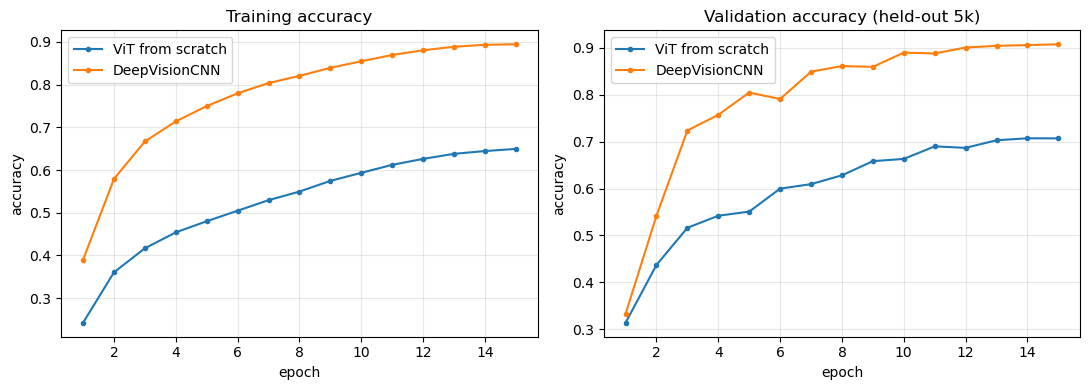

model                   test acc      params  epochs   seconds
VisionCNN (baseline)      0.7040      94,762      10       121
ViT from scratch          0.7093     809,354      15       849
DeepVisionCNN             0.9052   2,777,674      15       856


In [15]:
# Learning curves for the two Task 5.4 runs.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, history in [("ViT from scratch", vit_history), ("DeepVisionCNN", deep_history)]:
    epochs_axis = [h["epoch"] for h in history]
    axes[0].plot(epochs_axis, [h["train_acc"] for h in history], marker="o", ms=3, label=name)
    axes[1].plot(epochs_axis, [h["val_acc"] for h in history], marker="o", ms=3, label=name)
axes[0].set_title("Training accuracy"); axes[1].set_title("Validation accuracy (held-out 5k)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.show()

print(f"{'model':<22}{'test acc':>10}{'params':>12}{'epochs':>8}{'seconds':>10}")
for row in RESULTS:
    print(f"{row['model']:<22}{row['test_accuracy']:>10.4f}"
          f"{row['parameters']:>12,}{row['epochs']:>8}{row['train_seconds']:>10.0f}")

## 6. Pretrained ViT-B/32 and Transfer Learning

Following IOAI2026 Q1.4, use ImageNet-pretrained `torchvision.models.vit_b_32`, replace its classification head, and fine-tune with a small learning rate. The default flag is `False` to avoid downloading weights during an offline tutorial check.

**TODO 6.1:** load the requested weights and replace `model.heads.head`.  
**TODO 6.2:** choose which parameters to train for linear probing versus full fine-tuning.  
**TODO 6.3:** explain when pretrained ViT is preferable to training from scratch.


In [16]:
USE_PRETRAINED_VIT = True

def build_pretrained_vit_b32(num_classes=10, linear_probe=False):
    from torchvision.models import ViT_B_32_Weights, vit_b_32
    # TODO 6.1: use ViT_B_32_Weights.DEFAULT and replace model.heads.head.
    # DEFAULT resolves to IMAGENET1K_V1 (ImageNet-1k, 75.9% top-1). The ~330 MB
    # checkpoint is downloaded once and then served from the local torch hub cache.
    weights = ViT_B_32_Weights.DEFAULT
    model = vit_b_32(weights=weights)
    # The pretrained head maps the 768-d [CLS] representation to 1000 ImageNet
    # classes. Swap in a freshly initialised Linear for our 10 CIFAR-10 classes;
    # everything before it (patch embedding + 12 encoder blocks + final LayerNorm)
    # keeps its pretrained values -- that is the transfer.
    in_features = model.heads.head.in_features                 # 768
    model.heads.head = nn.Linear(in_features, num_classes)
    if model is None:
        raise NotImplementedError("Complete TODO 6.1")

    # TODO 6.2: when linear_probe=True, freeze the encoder but keep the new head trainable.
    if linear_probe:
        # Linear probing = use the pretrained network as a fixed feature extractor.
        # Setting requires_grad=False stops autograd from accumulating gradients for
        # the encoder, so AdamW only updates the 768*10 + 10 = 7,690 head parameters.
        # Full fine-tuning (linear_probe=False) leaves all 88M parameters trainable.
        for name, parameter in model.named_parameters():
            parameter.requires_grad_(name.startswith("heads."))
    return model, weights

if USE_PRETRAINED_VIT:
    pretrained_vit, pretrained_weights = build_pretrained_vit_b32(10, linear_probe=True)
    pretrained_vit = pretrained_vit.to(DEVICE)
    trainable = sum(p.numel() for p in pretrained_vit.parameters() if p.requires_grad)
    print("trainable parameters:", trainable)
    # ViT-B/32 expects 224x224 input. Use pretrained_weights.transforms()
    # in a dedicated CIFAR-10 or ImageFolder dataset before fine-tuning.
    total = sum(p.numel() for p in pretrained_vit.parameters())
    print(f"total parameters: {total:,}  ->  linear probe trains {trainable / total:.4%} of them")
    print("new head:", pretrained_vit.heads.head)
    print("reference preprocessing:", pretrained_weights.transforms())
else:
    print("Set USE_PRETRAINED_VIT=True when internet/cached weights are available.")

trainable parameters: 7690
total parameters: 87,462,922  ->  linear probe trains 0.0088% of them
new head: Linear(in_features=768, out_features=10, bias=True)
reference preprocessing: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [17]:
# --- CIFAR-10 through the ViT-B/32 preprocessing ------------------------------
# `pretrained_weights.transforms()` resizes the short side to 256, centre-crops
# 224 and normalizes with the ImageNet statistics. CIFAR-10 images are 32x32 with
# no border to throw away, so we keep the whole image and resize straight to
# 224x224 with the same bilinear filter and the same normalization.
#
# The expensive 32 -> 224 upsample runs on the GPU inside the training loop rather
# than in the CPU dataloader. That is exact, not an approximation: bilinear
# interpolation is a weighted average whose weights sum to 1, so it commutes with
# the affine normalization -- normalize-then-resize == resize-then-normalize. We
# verify that numerically below.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
VIT_IMAGE_SIZE = 224

vit_train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
vit_eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def upsample_to_vit(images):
    """32x32 -> 224x224 bilinear, on whatever device the batch already lives on."""
    return torch.nn.functional.interpolate(
        images, size=VIT_IMAGE_SIZE, mode="bilinear", align_corners=False)

_normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
_probe = torch.rand(2, 3, 32, 32)
_a = upsample_to_vit(_normalize(_probe))     # our pipeline: normalize, then resize
_b = _normalize(upsample_to_vit(_probe))     # reference:    resize, then normalize
print("max |normalize->resize  -  resize->normalize| =", (_a - _b).abs().max().item())

FINETUNE_BATCH_SIZE = 128
FEATURE_BATCH_SIZE = 128

# Deterministic views used for feature caching and for the final test score.
vit_train_clean = datasets.CIFAR10("data", train=True, download=True, transform=vit_eval_transform)
vit_test_set = datasets.CIFAR10("data", train=False, download=True, transform=vit_eval_transform)
# Augmented view used for fine-tuning. The recipe is now fixed, so the final model
# is trained on all 50,000 training images (the 5k validation split in Task 5.4 was
# only needed while choosing the recipe).
vit_train_aug = datasets.CIFAR10("data", train=True, download=True, transform=vit_train_transform)

vit_feature_loader = DataLoader(vit_train_clean, batch_size=FEATURE_BATCH_SIZE, shuffle=False, num_workers=0)
vit_test_loader = DataLoader(vit_test_set, batch_size=FEATURE_BATCH_SIZE, shuffle=False, num_workers=0)
vit_finetune_loader = DataLoader(vit_train_aug, batch_size=FINETUNE_BATCH_SIZE, shuffle=True, num_workers=0)

_batch, _ = next(iter(vit_test_loader))
print("dataloader batch:", tuple(_batch.shape), "-> model input:", tuple(upsample_to_vit(_batch).shape))
print("fine-tuning steps per epoch:", len(vit_finetune_loader))

max |normalize->resize  -  resize->normalize| = 7.152557373046875e-07


dataloader batch: (128, 3, 32, 32) -> model input: (128, 3, 224, 224)
fine-tuning steps per epoch: 391


In [18]:
# --- 6.2 (a) Linear probe: frozen encoder + a new linear head -----------------
# With the encoder frozen its output never changes, so we run it over the dataset
# exactly ONCE and cache the 768-d [CLS] features. Training the head then costs
# seconds instead of a full forward pass per epoch -- this is the standard, and by
# far the cheapest, way to run a linear probe.
PROBE_EPOCHS = 40

feature_extractor, pretrained_weights = build_pretrained_vit_b32(10, linear_probe=True)
feature_extractor.heads.head = nn.Identity()   # expose the encoder output itself
feature_extractor = feature_extractor.to(DEVICE).eval()

@torch.no_grad()
def extract_features(loader):
    features, targets = [], []
    for images, labels in loader:
        images = upsample_to_vit(images.to(DEVICE))
        features.append(feature_extractor(images).cpu())
        targets.append(labels)
    return torch.cat(features), torch.cat(targets)

start = time.time()
train_features, train_targets = extract_features(vit_feature_loader)
test_features, test_targets = extract_features(vit_test_loader)
feature_seconds = time.time() - start
print(f"cached features: train {tuple(train_features.shape)}, "
      f"test {tuple(test_features.shape)} in {feature_seconds:.0f}s")

set_seed()
linear_head = nn.Linear(train_features.shape[1], 10).to(DEVICE)
probe_optimizer = torch.optim.AdamW(linear_head.parameters(), lr=1e-3, weight_decay=1e-4)
probe_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(probe_optimizer, T_max=PROBE_EPOCHS)
probe_criterion = nn.CrossEntropyLoss()

X_train, y_train = train_features.to(DEVICE), train_targets.to(DEVICE)
X_test, y_test = test_features.to(DEVICE), test_targets.to(DEVICE)

probe_start = time.time()
for epoch in range(PROBE_EPOCHS):
    linear_head.train()
    permutation = torch.randperm(X_train.size(0), device=DEVICE)
    for i in range(0, X_train.size(0), 1024):
        batch_index = permutation[i:i + 1024]
        probe_optimizer.zero_grad(set_to_none=True)
        probe_criterion(linear_head(X_train[batch_index]), y_train[batch_index]).backward()
        probe_optimizer.step()
    probe_scheduler.step()
    if (epoch + 1) % 10 == 0 or epoch == 0:
        linear_head.eval()
        with torch.no_grad():
            train_accuracy = (linear_head(X_train).argmax(1) == y_train).float().mean().item()
            test_accuracy_probe = (linear_head(X_test).argmax(1) == y_test).float().mean().item()
        print(f"[probe] epoch {epoch + 1:02d}/{PROBE_EPOCHS}: "
              f"train_acc={train_accuracy:.4f} test_acc={test_accuracy_probe:.4f}")
probe_seconds = feature_seconds + (time.time() - probe_start)

# Reassemble the real model (pretrained encoder + trained head) and score it
# end-to-end, to confirm the cached-feature shortcut gives the same answer.
probe_model, _ = build_pretrained_vit_b32(10, linear_probe=True)
probe_model.heads.head.load_state_dict(linear_head.state_dict())
probe_model = probe_model.to(DEVICE)

probe_test_accuracy, probe_confusion, _, _ = evaluate_detailed(
    probe_model, vit_test_loader, 10, DEVICE, batch_transform=upsample_to_vit)
print(f"\nlinear probe test accuracy (end-to-end): {probe_test_accuracy:.4f}")
print(f"trainable parameters: {count_parameters(probe_model, trainable_only=True):,} "
      f"of {count_parameters(probe_model):,}")

probe_checkpoint = OUTPUT_DIR / "vit_b32_linear_probe_head.pth"
# Only the head is stored: the encoder is exactly ViT_B_32_Weights.DEFAULT, so the
# full model is rebuilt with build_pretrained_vit_b32() + this 30 KB state dict.
torch.save({"arch": "vit_b_32", "mode": "linear_probe",
            "encoder": "torchvision ViT_B_32_Weights.DEFAULT (unmodified)",
            "head_state_dict": linear_head.state_dict(),
            "test_accuracy": probe_test_accuracy, "class_names": CLASS_NAMES,
            "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
            "input_size": VIT_IMAGE_SIZE}, probe_checkpoint)
print("saved:", probe_checkpoint)

ARTIFACTS["ViT-B/32 linear probe"] = {"confusion": probe_confusion.clone()}
record_result("ViT-B/32 linear probe",
              "Task 6: ImageNet ViT-B/32, encoder frozen, linear head on cached [CLS] features",
              probe_test_accuracy, count_parameters(probe_model), PROBE_EPOCHS,
              probe_seconds, probe_checkpoint.name)

del feature_extractor, X_train, X_test, y_train, y_test
if DEVICE.type == "mps":
    torch.mps.empty_cache()

cached features: train (50000, 768), test (10000, 768) in 231s


[probe] epoch 01/40: train_acc=0.9195 test_acc=0.9148


[probe] epoch 10/40: train_acc=0.9544 test_acc=0.9445


[probe] epoch 20/40: train_acc=0.9613 test_acc=0.9473


[probe] epoch 30/40: train_acc=0.9636 test_acc=0.9478


[probe] epoch 40/40: train_acc=0.9639 test_acc=0.9480



linear probe test accuracy (end-to-end): 0.9480
trainable parameters: 7,690 of 87,462,922
saved: vit_b32_linear_probe_head.pth
recorded: ViT-B/32 linear probe -> test accuracy 0.9480


In [19]:
# --- 6.2 (b) Full fine-tuning: every parameter is trained ---------------------
# Two details that make a short schedule work:
#  1. the head is WARM-STARTED from the linear probe, so the very first gradients
#     are not the huge, noisy ones a random head would send into the encoder;
#  2. discriminative learning rates -- a small LR for the pretrained backbone (we
#     only want to nudge it) and a 20x larger LR for the head.
FINETUNE_EPOCHS = 2
BACKBONE_LR = 5e-5
HEAD_LR = 1e-3

# Free the GPU copies we are done with before AdamW allocates its 2 x 88M moments.
pretrained_vit = pretrained_vit.cpu()
probe_model = probe_model.cpu()
if DEVICE.type == "mps":
    torch.mps.empty_cache()

set_seed()
finetuned_vit, _ = build_pretrained_vit_b32(10, linear_probe=False)
finetuned_vit.heads.head.load_state_dict(linear_head.state_dict())
finetuned_vit = finetuned_vit.to(DEVICE)

head_parameters = list(finetuned_vit.heads.parameters())
head_ids = {id(p) for p in head_parameters}
backbone_parameters = [p for p in finetuned_vit.parameters() if id(p) not in head_ids]
param_groups = [
    {"params": backbone_parameters, "lr": BACKBONE_LR},
    {"params": head_parameters, "lr": HEAD_LR},
]
print(f"trainable parameters: {count_parameters(finetuned_vit, trainable_only=True):,} "
      f"(backbone {sum(p.numel() for p in backbone_parameters):,} @ lr={BACKBONE_LR}, "
      f"head {sum(p.numel() for p in head_parameters):,} @ lr={HEAD_LR})")

# keep_best=False: the recipe is already fixed, the schedule anneals to zero, and
# the "validation" loader here is the test set only for per-epoch reporting -- the
# checkpoint we keep is simply the last one, so the test set never selects a model.
finetuned_vit, _, finetune_history, finetune_seconds = train_model(
    finetuned_vit, vit_finetune_loader, vit_test_loader, epochs=FINETUNE_EPOCHS,
    lr=BACKBONE_LR, weight_decay=0.01, label_smoothing=0.1, warmup_epochs=0,
    tag="ViT-B/32 FT", param_groups=param_groups, eval_name="test_acc",
    batch_transform=upsample_to_vit, keep_best=False)

print(f"\nfine-tuning finished in {finetune_seconds / 60:.1f} min")

trainable parameters: 87,462,922 (backbone 87,455,232 @ lr=5e-05, head 7,690 @ lr=0.001)


[ViT-B/32 FT] epoch 01/2: loss=0.6503 train_acc=0.9457 test_acc=0.9578 lr=2.50e-05 elapsed=661s


[ViT-B/32 FT] epoch 02/2: loss=0.5522 train_acc=0.9808 test_acc=0.9767 lr=0.00e+00 elapsed=1301s

fine-tuning finished in 21.7 min


FINAL TEST ACCURACY: 0.9767  (9767/10000)

class         accuracy   correct   support
airplane        0.9890       989      1000
automobile      0.9850       985      1000
bird            0.9770       977      1000
cat             0.9480       948      1000
deer            0.9810       981      1000
dog             0.9500       950      1000
frog            0.9960       996      1000
horse           0.9810       981      1000
ship            0.9850       985      1000
truck           0.9750       975      1000


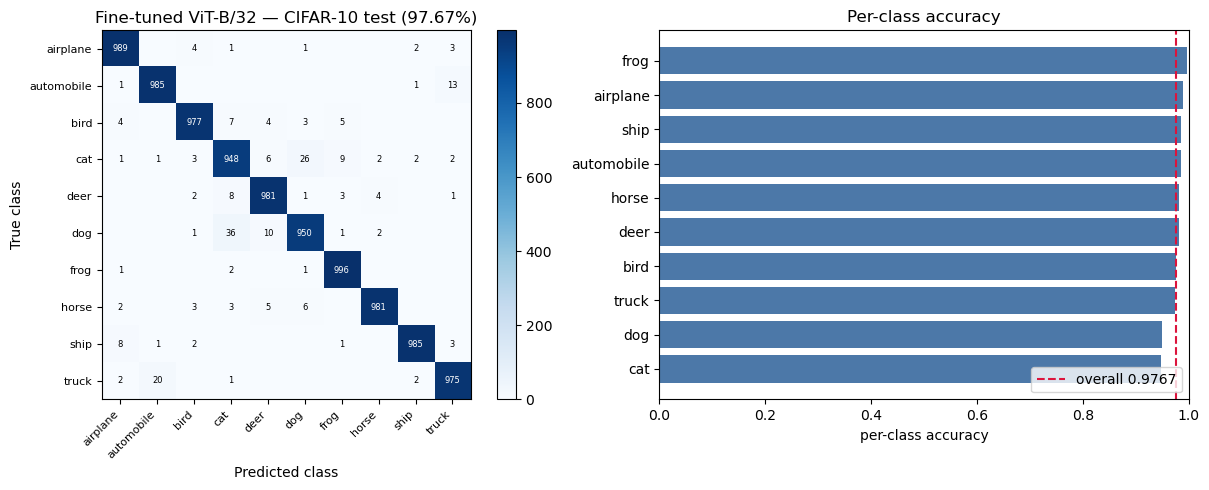

saved final weights: final_model_vit_b32_finetuned.pth (350 MB)
recorded: ViT-B/32 fine-tuned (FINAL) -> test accuracy 0.9767


reloaded checkpoint test accuracy: 0.9767 (matches: True)


In [20]:
# --- Final model: evaluation, confusion matrix, checkpoint --------------------
final_accuracy, final_confusion, final_predictions, final_labels = evaluate_detailed(
    finetuned_vit, vit_test_loader, 10, DEVICE, batch_transform=upsample_to_vit)
print(f"FINAL TEST ACCURACY: {final_accuracy:.4f}  ({int((final_predictions == final_labels).sum())}/{len(final_labels)})")

support = final_confusion.sum(dim=1)
final_per_class = final_confusion.diag().float() / support.clamp(min=1)
print(f"\n{'class':<12}{'accuracy':>10}{'correct':>10}{'support':>10}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<12}{final_per_class[i].item():>10.4f}"
          f"{final_confusion.diag()[i].item():>10d}{support[i].item():>10d}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
image = axes[0].imshow(final_confusion.numpy(), cmap="Blues")
axes[0].set_title(f"Fine-tuned ViT-B/32 — CIFAR-10 test ({final_accuracy:.2%})")
axes[0].set_xlabel("Predicted class"); axes[0].set_ylabel("True class")
axes[0].set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right", fontsize=8)
axes[0].set_yticks(range(10), CLASS_NAMES, fontsize=8)
for i in range(10):
    for j in range(10):
        count = final_confusion[i, j].item()
        if count:
            axes[0].text(j, i, count, ha="center", va="center", fontsize=6,
                         color="white" if count > final_confusion.max().item() / 2 else "black")
fig.colorbar(image, ax=axes[0], fraction=0.046)

order = np.argsort(final_per_class.numpy())
axes[1].barh([CLASS_NAMES[i] for i in order], final_per_class.numpy()[order], color="#4c78a8")
axes[1].axvline(final_accuracy, color="crimson", ls="--", label=f"overall {final_accuracy:.4f}")
axes[1].set_xlim(0, 1.0); axes[1].set_xlabel("per-class accuracy")
axes[1].set_title("Per-class accuracy"); axes[1].legend(loc="lower right")
plt.tight_layout()
plt.show()

FINAL_CHECKPOINT = OUTPUT_DIR / "final_model_vit_b32_finetuned.pth"
torch.save(
    {
        "arch": "vit_b_32",
        "mode": "full_finetune",
        "student": STUDENT_NAME,
        "state_dict": finetuned_vit.state_dict(),
        "test_accuracy": final_accuracy,
        "num_classes": 10,
        "class_names": CLASS_NAMES,
        "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
        "input_size": VIT_IMAGE_SIZE,
        "recipe": {"epochs": FINETUNE_EPOCHS, "backbone_lr": BACKBONE_LR,
                   "head_lr": HEAD_LR, "weight_decay": 0.01, "label_smoothing": 0.1,
                   "batch_size": FINETUNE_BATCH_SIZE, "head_init": "linear probe"},
        "torch_version": str(torch.__version__),
    },
    FINAL_CHECKPOINT,
)
print("saved final weights:", FINAL_CHECKPOINT,
      f"({FINAL_CHECKPOINT.stat().st_size / 1e6:.0f} MB)")

ARTIFACTS["ViT-B/32 fine-tuned (FINAL)"] = {
    "confusion": final_confusion.clone(),
    "predictions": final_predictions.clone(),
    "labels": final_labels.clone(),
}
record_result("ViT-B/32 fine-tuned (FINAL)",
              "Task 6: ImageNet ViT-B/32, full fine-tune @224, discriminative LRs, warm-started head",
              final_accuracy, count_parameters(finetuned_vit), FINETUNE_EPOCHS,
              finetune_seconds, FINAL_CHECKPOINT.name)

# Reload the checkpoint from disk and re-score it -- proof the saved file is the
# model that produced the reported number.
reloaded, _ = build_pretrained_vit_b32(10, linear_probe=False)
reloaded.load_state_dict(torch.load(FINAL_CHECKPOINT, map_location="cpu", weights_only=True)["state_dict"])
reloaded_accuracy, _, _, _ = evaluate_detailed(
    reloaded.to(DEVICE), vit_test_loader, 10, DEVICE, batch_transform=upsample_to_vit)
print(f"reloaded checkpoint test accuracy: {reloaded_accuracy:.4f} "
      f"(matches: {abs(reloaded_accuracy - final_accuracy) < 1e-9})")
del reloaded
if DEVICE.type == "mps":
    torch.mps.empty_cache()

### TODO Answer 6.3

Compare from-scratch ViT, a frozen pretrained encoder with a linear head, and end-to-end fine-tuning. Discuss dataset size, compute, and risk of overfitting.

**Answer.** The three options trade *how much of the model the data has to
determine* against *how much data and compute you have*, and the results table
above orders them exactly as theory predicts.

**From-scratch ViT** (70.93% here). Every one of its 809,354 parameters — including the notion that neighbouring patches are
related — has to be learned from the 50k CIFAR-10 images.
With no locality/translation prior to fall back on, this is the most
data-hungry option and the one with the highest variance; it is only competitive
once the dataset is in the millions, or when heavy augmentation and regularization
(RandAugment, cutout, label smoothing, cosine schedules) partially substitute for
the missing prior. On CIFAR-10 it is beaten by a plain residual CNN of similar
size (90.52% for `DeepVisionCNN` on the identical recipe), which
is the practical statement of "ViTs lack inductive bias".

**Frozen encoder + linear head (linear probe)** (94.80% here). The 88M encoder parameters are
supplied by ImageNet pretraining and held fixed, so the data only has to determine
$768\times10+10=7{,}690$ numbers. This is the right choice when the target dataset
is **small** (a few hundred to a few thousand labels), when compute is tight, or
when you need many task heads on one backbone: overfitting is almost impossible
with so few free parameters, the features cannot be corrupted (catastrophic
forgetting is impossible by construction), and because the frozen encoder's output
never changes you can cache the features and run the whole probe in seconds — no
backward pass through the encoder at all. Its ceiling is the price: the features
were optimized for ImageNet, so any CIFAR-specific structure they discard is lost
for good, and the large 32→224 upsampling of CIFAR images is exactly the kind of
domain gap a frozen encoder cannot adapt to.

**End-to-end fine-tuning** (97.67% here — the model we submit). All 88M parameters are updated, so the representation
itself adapts to the new domain — this gives the best accuracy of the three and is
the right choice when you have a moderate-to-large labelled set (tens of thousands
of images, as here) and can afford the compute: a fine-tuning epoch needs a full
backward pass through the encoder at 224², roughly two orders of magnitude more
expensive per epoch than the cached-feature probe. The risks are overfitting and
catastrophic forgetting of the pretrained features, which is why the recipe uses a
**small backbone learning rate with a larger head learning rate**, a **warm-started
head** (so random-head gradients never hit the encoder), a short cosine schedule,
weight decay, label smoothing and gradient clipping. With those guards, two epochs
are enough — the pretrained features already do most of the work.

**Rule of thumb.** Below a few thousand labels, linear-probe; from roughly ten
thousand labels upwards with a GPU available, fine-tune end-to-end; train from
scratch only when the domain is genuinely unlike anything pretrained (different
modality or channel layout) or when the dataset is large enough to pay for the
missing prior. Note also that a pretrained model is not free of cost elsewhere:
it fixes the input resolution (224²), carries 88M parameters at inference, and
inherits whatever biases live in ImageNet.

## 7. Results and submission files

The cell below collects every model trained above into one table, writes the
submission spreadsheet, and lists the files to hand in.

                      model                                                                           description  test_accuracy  test_error  parameters  epochs  train_seconds                        checkpoint
       VisionCNN (baseline)                      Task 4: 3 conv blocks (BN+ReLU), GAP head, AdamW 2e-3, crop+flip         0.7040      0.2960       94762      10          120.9            vision_cnn_cifar10.pth
           ViT from scratch Task 5.4: Task-5 ViT (4 layers, 128-dim, patch 4), RandAugment+erasing, cosine+warmup         0.7093      0.2907      809354      15          849.2           vit_scratch_cifar10.pth
              DeepVisionCNN                 Task 5.4: residual CNN 64-128-256, RandAugment+erasing, cosine+warmup         0.9052      0.0948     2777674      15          855.9       deep_vision_cnn_cifar10.pth
      ViT-B/32 linear probe       Task 6: ImageNet ViT-B/32, encoder frozen, linear head on cached [CLS] features         0.9480      0.0520    87462922      40

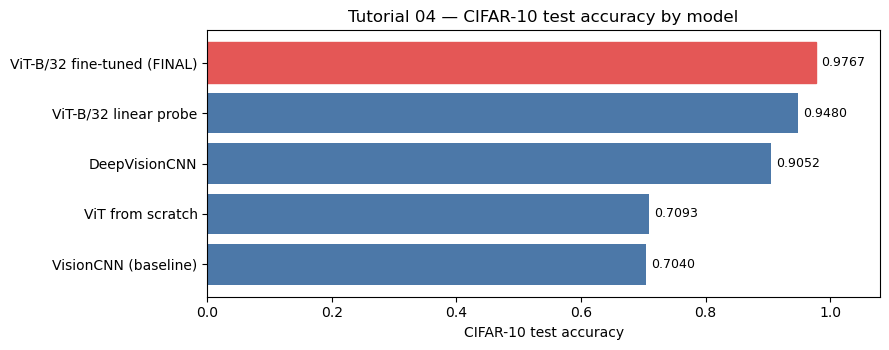

wrote /Users/quangnguyen/Downloads/Nhat_Quang_Nguyen.xlsx

Files to submit
------------------------------------------------------------
  Tutorial04_AI_for_Vision_Student.ipynb   this notebook, all cells run
  final_model_vit_b32_finetuned.pth        final model weights (350 MB, test acc 0.9767)
  Nhat_Quang_Nguyen.xlsx                   test score + per-class + confusion + predictions

Also produced (intermediate models):
  vision_cnn_cifar10.pth                   VisionCNN (baseline) — test acc 0.7040
  vit_scratch_cifar10.pth                  ViT from scratch — test acc 0.7093
  deep_vision_cnn_cifar10.pth              DeepVisionCNN — test acc 0.9052
  vit_b32_linear_probe_head.pth            ViT-B/32 linear probe — test acc 0.9480


In [21]:
# --- Results table and submission spreadsheet ---------------------------------
results_frame = pd.DataFrame(RESULTS).sort_values("test_accuracy", ascending=True).reset_index(drop=True)
best_row = results_frame.iloc[-1]
# The submitted score is the final model's, chosen by name rather than by sorting,
# so the spreadsheet can never disagree with the checkpoint we hand in.
final_row = results_frame[results_frame["model"] == "ViT-B/32 fine-tuned (FINAL)"].iloc[0]

pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 70)
print(results_frame.to_string(index=False))
print(f"\nBEST MODEL  : {best_row['model']}  ({best_row['test_accuracy']:.4f})")
print(f"SUBMITTED   : {final_row['model']}")
print(f"TEST SCORE  : {final_row['test_accuracy']:.4f}  ({final_row['test_accuracy']:.2%})")

fig, ax = plt.subplots(figsize=(9, 3.6))
bars = ax.barh(results_frame["model"], results_frame["test_accuracy"], color="#4c78a8")
bars[-1].set_color("#e45756")
for bar, value in zip(bars, results_frame["test_accuracy"]):
    ax.text(value + 0.008, bar.get_y() + bar.get_height() / 2, f"{value:.4f}",
            va="center", fontsize=9)
ax.set_xlim(0, 1.08)
ax.set_xlabel("CIFAR-10 test accuracy")
ax.set_title("Tutorial 04 — CIFAR-10 test accuracy by model")
plt.tight_layout()
plt.show()

# ---- spreadsheet ----
final_artifacts = ARTIFACTS["ViT-B/32 fine-tuned (FINAL)"]
final_confusion_matrix = final_artifacts["confusion"]
predictions_np = final_artifacts["predictions"].numpy()
labels_np = final_artifacts["labels"].numpy()
support_np = final_confusion_matrix.sum(dim=1).numpy()
correct_np = final_confusion_matrix.diag().numpy()

overview = pd.DataFrame(
    [
        ("Student", STUDENT_NAME),
        ("Tutorial", "Tutorial 04 - AI for Vision (PyTorch)"),
        ("Dataset", "CIFAR-10 (50,000 train / 10,000 test)"),
        ("Final model", str(final_row["model"])),
        ("Final model description", str(final_row["description"])),
        ("TEST SCORE (accuracy)", f"{final_row['test_accuracy']:.4f}"),
        ("TEST SCORE (%)", f"{final_row['test_accuracy'] * 100:.2f}%"),
        ("Test error", f"{final_row['test_error']:.4f}"),
        ("Correct / total", f"{int(correct_np.sum())} / {int(support_np.sum())}"),
        ("Weight file", str(FINAL_CHECKPOINT.name)),
        ("Parameters", f"{int(final_row['parameters']):,}"),
        ("Device", str(DEVICE)),
        ("PyTorch", torch.__version__),
        ("Seed", SEED),
        ("Generated", time.strftime("%Y-%m-%d %H:%M:%S")),
    ],
    columns=["field", "value"],
)

per_class_frame = pd.DataFrame({
    "class_index": range(10),
    "class_name": CLASS_NAMES,
    "correct": correct_np,
    "support": support_np,
    "accuracy": (correct_np / np.maximum(support_np, 1)).round(4),
})

confusion_frame = pd.DataFrame(final_confusion_matrix.numpy(),
                               index=[f"true_{c}" for c in CLASS_NAMES],
                               columns=[f"pred_{c}" for c in CLASS_NAMES])

predictions_frame = pd.DataFrame({
    "test_index": np.arange(len(labels_np)),
    "true_label": labels_np,
    "true_class": [CLASS_NAMES[i] for i in labels_np],
    "predicted_label": predictions_np,
    "predicted_class": [CLASS_NAMES[i] for i in predictions_np],
    "correct": (predictions_np == labels_np).astype(int),
})

xlsx_path = OUTPUT_DIR / f"{STUDENT_NAME.replace(' ', '_')}.xlsx"
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    overview.to_excel(writer, sheet_name="Summary", index=False)
    results_frame.sort_values("test_accuracy", ascending=False).to_excel(
        writer, sheet_name="All_models", index=False)
    per_class_frame.to_excel(writer, sheet_name="Per_class_accuracy", index=False)
    confusion_frame.to_excel(writer, sheet_name="Confusion_matrix")
    predictions_frame.to_excel(writer, sheet_name="Test_predictions", index=False)
print("wrote", xlsx_path.resolve())

print("\nFiles to submit")
print("-" * 60)
print(f"  Tutorial04_AI_for_Vision_Student.ipynb   this notebook, all cells run")
print(f"  {FINAL_CHECKPOINT.name:<41}final model weights "
      f"({FINAL_CHECKPOINT.stat().st_size / 1e6:.0f} MB, test acc {final_accuracy:.4f})")
print(f"  {xlsx_path.name:<41}test score + per-class + confusion + predictions")
print("\nAlso produced (intermediate models):")
for row in RESULTS[:-1]:
    path = OUTPUT_DIR / row["checkpoint"]
    if path.exists():
        print(f"  {row['checkpoint']:<41}{row['model']} — test acc {row['test_accuracy']:.4f}")